%% [markdown]
# 📊 Capítulo 7: Algorithmic Trading con IA/ML
*El límite del motor: Cuando las reglas ceden el testigo al aprendizaje automático*

**Estrategia:** Un modelo Random Forest Classifier predice la probabilidad de rentabilidad positiva del SPY a 5 días vista, usando features de momentum, volatilidad y mean reversion. 

**Objetivo:** Demostrar cómo integrar un modelo de ML en el Motor Dinámico, la importancia crítica del Walk-Forward Validation para evitar overfitting, y la dura realidad de la ratio señal/ruido en los mercados financieros.


## BLOQUE 0: CONFIGURACIÓN — IA/ML

In [1]:
# %%
# ==============================================================================
# BLOQUE 0: CONFIGURACIÓN — IA/ML
# ==============================================================================

# --- Parámetros financieros ---
CAPITAL_INICIAL      = 10000
COSTE_TRANSACCION    = 0.001
BENCHMARK            = 'SPY'

# --- Rango temporal ---
FECHA_INICIO = '2010-01-01' # Necesitamos datos desde 2008 para el warm-up de features
FECHA_FIN    = '2025-08-15'

# --- Parámetros de Machine Learning ---
ML_MODELO            = 'RandomForest' # Opciones: 'RandomForest', 'XGBoost'
HORIZONTE_PREDICCION = 5              # Días para el target (1 semana bursátil)
UMBRAL_CONFIANZA_ALTA = 0.60          # Si P(Subida) > 60% -> 100% SPY
UMBRAL_CONFIANZA_BAJA = 0.40          # Si P(Subida) < 40% -> 100% SHV
FRECUENCIA_REENTRENAMIENTO = 21       # Retrainar el modelo cada 21 días (mensual)

# --- Universo ---
UNIVERSO_ML = {
    'rv_usa': {
        'SPDR S&P 500': {'isin': 'SPY', 'ticker': 'SPY'},
    },
    'cash': {
        'iShares 1-3 Year Treasury': {'isin': 'SHY', 'ticker': 'SHY'},  # ← Cambiado de SHV a SHY
    },
    'volatilidad': {
        'CBOE Volatility Index': {'isin': '^VIX', 'ticker': '^VIX'},  # ← VIX spot
    }
}
print("✅ Configuración ML cargada.")
print(f"   • Modelo: {ML_MODELO}")
print(f"   • Horizonte: {HORIZONTE_PREDICCION} días")
print(f"   • Umbrales de confianza: [{UMBRAL_CONFIANZA_BAJA}, {UMBRAL_CONFIANZA_ALTA}]")

✅ Configuración ML cargada.
   • Modelo: RandomForest
   • Horizonte: 5 días
   • Umbrales de confianza: [0.4, 0.6]


## BLOQUE 1: ENTORNO E IMPORTACIONES

In [2]:
# %%
# ==============================================================================
# BLOQUE 1: ENTORNO E IMPORTACIONES
# ==============================================================================
print("="*70)
print("⚠️  AVISO LEGAL: Fines exclusivamente educativos e investigativos.")
print("="*70)

import sys, os, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Búsqueda de core (misma lógica que en capítulos anteriores)
def buscar_core():
    try:
        import ipykernel
        from jupyter_server import serverapp as app_module
        import json, re, urllib.request
        connection_file = os.path.basename(ipykernel.get_connection_file())
        match = re.search(r'kernel-(.*)\.json', connection_file)
        if match:
            kernel_id = match.group(1)
            for srv in app_module.list_running_servers():
                try:
                    url = srv['url'] + 'api/sessions'
                    token = srv.get('token', '')
                    headers = {'Authorization': f'token {token}'} if token else {}
                    req = urllib.request.Request(url, headers=headers)
                    with urllib.request.urlopen(req, timeout=2) as resp:
                        sessions = json.loads(resp.read())
                    for sess in sessions:
                        if sess.get('kernel', {}).get('id') == kernel_id:
                            ruta_nb = os.path.join(srv['root_dir'], sess['notebook']['path'])
                            ruta_dir = os.path.dirname(os.path.abspath(ruta_nb))
                            actual = Path(ruta_dir)
                            for parent in [actual] + list(actual.parents):
                                if (parent / 'core').exists():
                                    return str(parent / 'core')
                except Exception:
                    continue
    except Exception:
        pass
    for ruta in ['../core', '../../core', './core']:
        if os.path.isdir(ruta):
            return os.path.abspath(ruta)
    return None

# [parche-colab] En Colab solo se carga el .ipynb: se clona el repo para disponer de 'core/'
if "google.colab" in sys.modules:
    import subprocess
    _REPO = "/content/Estrategias_No_Convencionales"
    if not os.path.isdir(os.path.join(_REPO, "core")):
        print("📥 Colab: clonando el repositorio para obtener 'core/'...")
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/akitxu/Estrategias_No_Convencionales.git", _REPO], check=True)
    os.chdir(os.path.join(_REPO, "notebooks"))   # así buscar_core() encuentra '../core'

RUTA_CORE = buscar_core()
if RUTA_CORE and os.path.isdir(RUTA_CORE):
    sys.path.insert(0, os.path.dirname(RUTA_CORE))
    print(f"✅ Carpeta 'core' localizada: {RUTA_CORE}")

try:
    from core import (
        GestorProyecto, GestorDatos, MotorBacktestDinamico,
        CalculadorMetricas, CalculadorMetricasExtras, GeneradorInformes,
        StatArbEngine # ← NUEVO
    )
    print("✅ Módulos importados correctamente (incluye StatArbEngine).")
except ImportError as e:
    print(f"❌ Error importando módulos: {e}")
    raise

BASE_DIR = os.path.dirname(RUTA_CORE) if RUTA_CORE else os.getcwd()

⚠️  AVISO LEGAL: Fines exclusivamente educativos e investigativos.
✅ Carpeta 'core' localizada: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
✅ Módulos importados correctamente (incluye StatArbEngine).


## Bloques 2 y 3: Limpieza y Fechas

In [3]:
# %%
# ==============================================================================
# BLOQUE 2: LIMPIEZA DE DIRECTORIOS
# ==============================================================================
gestor_proyecto = GestorProyecto(base_dir_manual=BASE_DIR)
gestor_proyecto.imprimir_resumen()
gestor_proyecto.menu_limpieza_directorios()

# %%
# ==============================================================================
# BLOQUE 3: GESTIÓN DE FECHAS
# ==============================================================================
fecha_ini = FECHA_INICIO
fecha_fin = FECHA_FIN
nombre_evento = "Crisis Bancaria y Post-Pandemia (2015-2025)"
print(f"\n🎯 Rango temporal: {nombre_evento} | {fecha_ini} → {fecha_fin}")

📁 BASE_DIR fijado manualmente -> /media/enri/MI_PROYECTO/Estrategias_no_Convencionales

🔍 ENTORNO CONFIGURADO
📂 Base: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales
📁 CORE                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
📁 CHAPTERS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/chapters
📁 LOGS                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/logs
📁 DATOS               : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos
📁 OUTPUTS             : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs
📁 CARTERAS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/carteras
📁 DATOS_CSV           : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_csv
📁 DATOS_FI_GESTORA    : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_gestora
📁 DATOS_FI_INVESTING  : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_investing
📁 DATOS_FI_MYI


¿Qué directorios deseas VACIAR? (ej: 3,5,7 / 'todos' / 'ninguno'):  5



🧹 Iniciando limpieza...
   🗑️  Vaciando 'DATOS_CSV'...
      ✅ 'DATOS_CSV' limpiado.

🎯 Rango temporal: Crisis Bancaria y Post-Pandemia (2015-2025) | 2010-01-01 → 2025-08-15


## BLOQUE 4: MENÚ DEL GESTOR DE DATOS

In [4]:
# %%
# ==============================================================================
# BLOQUE 4: MENÚ DEL GESTOR DE DATOS
# ==============================================================================

# --- Validación de variables necesarias ---
if 'UNIVERSO_STATARB' not in locals():
    print("️  UNIVERSO_STATARB no definido. Usando valores por defecto del Bloque 0...")
    UNIVERSO_STATARB = {
        'etf': {
            'Financial Select Sector': {'isin': 'XLF', 'ticker': 'XLF'},
        },
        'subyacentes': {
            'JPMorgan':       {'isin': 'JPM', 'ticker': 'JPM'},
            'Bank of America':{'isin': 'BAC', 'ticker': 'BAC'},
            'Wells Fargo':    {'isin': 'WFC', 'ticker': 'WFC'},
            'Goldman Sachs':  {'isin': 'GS',  'ticker': 'GS'},
            'Morgan Stanley': {'isin': 'MS',  'ticker': 'MS'},
            'Citigroup':      {'isin': 'C',   'ticker': 'C'},
            'BlackRock':      {'isin': 'BLK', 'ticker': 'BLK'},
            'Charles Schwab': {'isin': 'SCHW','ticker': 'SCHW'},
            'American Express':{'isin': 'AXP','ticker': 'AXP'},
            'PNC Financial':  {'isin': 'PNC', 'ticker': 'PNC'},
        },
        'benchmark': {
            'SPDR S&P 500':   {'isin': 'SPY', 'ticker': 'SPY'},
        }
    }

if 'gestor_proyecto' not in locals():
    print("⚠️  gestor_proyecto no inicializado. Creándolo automáticamente...")
    gestor_proyecto = GestorProyecto(base_dir_manual=BASE_DIR)
    gestor_proyecto.imprimir_resumen()

if 'fecha_ini' not in locals() or 'fecha_fin' not in locals():
    print("⚠️  Fechas no definidas. Usando valores por defecto (2015-2025)...")
    fecha_ini = '2015-01-01'
    fecha_fin = '2025-08-15'

# --- Inicialización del Gestor de Datos ---
gestor = GestorDatos(
    diccionario_datos=UNIVERSO_STATARB,
    fecha_inicio=fecha_ini,
    fecha_fin=fecha_fin,
    gestor_proyecto=gestor_proyecto
)

print(f"\n GestorDatos inicializado con {len(UNIVERSO_STATARB)} categorías.")
continuar = gestor.menu()

if not continuar:
    print("⛔ Usuario canceló.")
else:
    print("\n✅ Datos preparados.")

️  UNIVERSO_STATARB no definido. Usando valores por defecto del Bloque 0...

 GestorDatos inicializado con 3 categorías.

 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  1



🗑️ Limpiando CSVs antiguos y descargando desde Yahoo Finance...

📊 Procesando 12 activos...

   📊 Financial Select Sector
      ✅ Descargado con ticker: XLF

   📊 JPMorgan
      ✅ Descargado con ticker: JPM

   📊 Bank of America
      ✅ Descargado con ticker: BAC

   📊 Wells Fargo
      ✅ Descargado con ticker: WFC

   📊 Goldman Sachs
      ✅ Descargado con ticker: GS

   📊 Morgan Stanley
      ✅ Descargado con ticker: MS

   📊 Citigroup
      ✅ Descargado con ticker: C

   📊 BlackRock
      ✅ Descargado con ticker: BLK

   📊 Charles Schwab
      ✅ Descargado con ticker: SCHW

   📊 American Express
      ✅ Descargado con ticker: AXP

   📊 PNC Financial
      ✅ Descargado con ticker: PNC

   📊 SPDR S&P 500
      ✅ Descargado con ticker: SPY

📊 Resumen: 12 descargados, 0 omitidos



Presiona Enter para continuar... 



 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  6



✅ Datos aceptados para el backtest.
📝 No hay Excel cargado. Generando cartera automática (60/40) desde el diccionario...

🧼 INFORME DE LIMPIEZA DE DATOS


,Activo,ISIN,Filas,Desde,Hasta,Fuente
0,Financial Select Sector,XLF,3928,2010-01-04,2025-08-14,CSV
1,JPMorgan,JPM,3928,2010-01-04,2025-08-14,CSV
2,Bank of America,BAC,3928,2010-01-04,2025-08-14,CSV
3,Wells Fargo,WFC,3928,2010-01-04,2025-08-14,CSV
4,Goldman Sachs,GS,3928,2010-01-04,2025-08-14,CSV
5,Morgan Stanley,MS,3928,2010-01-04,2025-08-14,CSV
6,Citigroup,C,3928,2010-01-04,2025-08-14,CSV
7,BlackRock,BLK,3928,2010-01-04,2025-08-14,CSV
8,Charles Schwab,SCHW,3928,2010-01-04,2025-08-14,CSV
9,American Express,AXP,3928,2010-01-04,2025-08-14,CSV


✅ 12 activos alineados para el Motor Backtest.


✅ Datos preparados.


## BLOQUE 5: MOTOR ML Y GENERACIÓN DE SEÑALES (WALK-FORWARD)

In [5]:
# %%
# ==============================================================================
# BLOQUE 5: MOTOR ML Y GENERACIÓN DE SEÑALES (WALK-FORWARD)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*70)
print("🧠 FASE 1: INGENIERÍA DE FEATURES Y TARGET")
print("="*70)

# ==================================================================
# MAPEO ROBUSTO DE TICKERS A NOMBRES DE COLUMNA
# ==================================================================
print("\n🔍 Mapeando tickers a columnas reales...")

mapeo_tickers = {}
if hasattr(gestor, 'valores_seleccionados') and not gestor.valores_seleccionados.empty:
    for _, row in gestor.valores_seleccionados.iterrows():
        ticker = str(row.get('ticker', '')).strip().upper()
        nombre = str(row.get('nombre', '')).strip()
        nombre_limpio = nombre.replace(" ", "_").replace(".", "").replace(",", "").replace("!", "")
        if ticker:
            mapeo_tickers[ticker] = nombre_limpio

# Buscar columnas para SPY, SHY y VIX
col_spy = mapeo_tickers.get('SPY')
col_shy = mapeo_tickers.get('SHY')  # ← Cambiado de SHV a SHY
col_vix = mapeo_tickers.get('^VIX') or mapeo_tickers.get('VIX')

print(f"   • SPY → '{col_spy}' {'✅' if col_spy and col_spy in gestor.precios_ajustados.columns else ''}")
print(f"   • SHY → '{col_shy}' {'✅' if col_shy and col_shy in gestor.precios_ajustados.columns else '⚠️ (no disponible)'}")
print(f"   • VIX → '{col_vix}' {'✅' if col_vix and col_vix in gestor.precios_ajustados.columns else '⚠️ (opcional)'}")

if not col_spy or col_spy not in gestor.precios_ajustados.columns:
    print("\n❌ No se encontró la columna del SPY. Abortando Bloque 5.")
else:
    # Construir DataFrame con las columnas disponibles
    cols_disponibles = [col_spy]
    if col_shy and col_shy in gestor.precios_ajustados.columns:
        cols_disponibles.append(col_shy)
    if col_vix and col_vix in gestor.precios_ajustados.columns:
        cols_disponibles.append(col_vix)
    
    df = gestor.precios_ajustados[cols_disponibles].copy()
    
    # Renombrar columnas
    rename_map = {}
    if col_spy: rename_map[col_spy] = 'SPY'
    if col_shy and col_shy in cols_disponibles: rename_map[col_shy] = 'SHY'  # ← Cambiado
    if col_vix and col_vix in cols_disponibles: rename_map[col_vix] = 'VIX'
    df = df.rename(columns=rename_map)
    
    print(f"\n✅ DataFrame construido con {len(df)} filas y columnas: {list(df.columns)}")

    # ==================================================================
    # 1. CREAR FEATURES (X)
    # ==================================================================
    print("\n🔧 Calculando features...")
    
    # Momentum
    df['ret_1m'] = df['SPY'].pct_change(21)
    df['ret_3m'] = df['SPY'].pct_change(63)
    df['ret_6m'] = df['SPY'].pct_change(126)
    
    # Volatilidad
    df['vol_20d'] = df['SPY'].pct_change().rolling(20).std() * np.sqrt(252)
    df['vol_60d'] = df['SPY'].pct_change().rolling(60).std() * np.sqrt(252)
    
    # Distancia a medias móviles
    df['dist_sma50'] = (df['SPY'] / df['SPY'].rolling(50).mean()) - 1
    df['dist_sma200'] = (df['SPY'] / df['SPY'].rolling(200).mean()) - 1
    
    # RSI(14) - cálculo correcto
    delta = df['SPY'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df['rsi_14'] = 100 - (100 / (1 + rs))
    
    # VIX (si está disponible) - usar como feature adicional
    if 'VIX' in df.columns:
        df['vix_level'] = df['VIX']
        df['vix_change'] = df['VIX'].pct_change(5)
    
    # ==================================================================
    # 2. CREAR TARGET (y): ¿Subirá el SPY en los próximos N días?
    # ==================================================================
    df['target'] = (df['SPY'].shift(-HORIZONTE_PREDICCION) > df['SPY']).astype(int)
    
    # Eliminar filas con NaN
    df_ml = df.dropna().copy()
    
    # Definir lista de features según disponibilidad
    features_base = ['ret_1m', 'ret_3m', 'ret_6m', 'vol_20d', 'vol_60d', 
                     'dist_sma50', 'dist_sma200', 'rsi_14']
    features_vix = ['vix_level', 'vix_change'] if 'VIX' in df_ml.columns else []
    features = features_base + features_vix
    
    X = df_ml[features]
    y = df_ml['target']
    
    print(f"✅ Dataset ML creado: {len(df_ml)} filas, {len(features)} features.")
    print(f"   • Features: {features}")
    print(f"   • Distribución del Target: {y.value_counts().to_dict()}")
    print(f"   • Balance de clases: {y.mean():.2%} subidas, {(1-y.mean()):.2%} bajadas")

    # ==================================================================
    # FASE 2: ENTRENAMIENTO WALK-FORWARD (SIN LOOK-AHEAD BIAS)
    # ==================================================================
    print("\n" + "="*70)
    print("🔄 FASE 2: ENTRENAMIENTO WALK-FORWARD")
    print("="*70)
    
    probabilidades = pd.Series(index=df_ml.index, dtype=float)
    modelo = RandomForestClassifier(
        n_estimators=100, 
        max_depth=5, 
        random_state=42, 
        min_samples_split=20,
        min_samples_leaf=10
    )
    
    # Empezamos a predecir cuando tenemos al menos 2 años de datos para entrenar
    inicio_prediccion = 504
    fechas_reentrenamiento = df_ml.index[inicio_prediccion::FRECUENCIA_REENTRENAMIENTO]
    
    print(f"📅 Reentrenamientos programados: {len(fechas_reentrenamiento)}")
    print(f"   • Primer entrenamiento: {fechas_reentrenamiento[0].date() if len(fechas_reentrenamiento) > 0 else 'N/A'}")
    print(f"   • Último entrenamiento: {fechas_reentrenamiento[-1].date() if len(fechas_reentrenamiento) > 0 else 'N/A'}")
    
    for i, fecha_retrain in enumerate(fechas_reentrenamiento):
        # Datos de entrenamiento hasta la fecha de reentrenamiento
        idx_train = df_ml.index < fecha_retrain
        X_train, y_train = X[idx_train], y[idx_train]
        
        # Validar que tenemos suficientes datos
        if len(X_train) < 100:
            continue
        
        # Entrenar
        modelo.fit(X_train, y_train)
        
        # Predecir para los próximos días hasta el siguiente reentrenamiento
        if i + 1 < len(fechas_reentrenamiento):
            fecha_next_retrain = fechas_reentrenamiento[i+1]
        else:
            fecha_next_retrain = df_ml.index[-1] + pd.Timedelta(days=1)
            
        idx_predict = (df_ml.index >= fecha_retrain) & (df_ml.index < fecha_next_retrain)
        
        if idx_predict.any():
            X_predict = X[idx_predict]
            # predict_proba devuelve [P(Clase 0), P(Clase 1)]. Nos quedamos con P(Clase 1) = P(Subida)
            probs = modelo.predict_proba(X_predict)[:, 1]
            probabilidades.loc[idx_predict] = probs
    
    # Asignar valor por defecto a los días antes del primer entrenamiento
    if len(fechas_reentrenamiento) > 0:
        probabilidades.loc[:fechas_reentrenamiento[0]] = 0.5
    
    df_ml['prob_subida'] = probabilidades
    
    print(f"\n✅ Predicciones Walk-Forward completadas.")
    print(f"   • Rango de predicciones: {df_ml['prob_subida'].first_valid_index().date()} → {df_ml['prob_subida'].last_valid_index().date()}")
    print(f"   • Media de probabilidades: {df_ml['prob_subida'].mean():.3f}")
    print(f"   • Desviación estándar: {df_ml['prob_subida'].std():.3f}")

    # ==================================================================
    # FASE 3: IMPORTANCIA DE FEATURES
    # ==================================================================
    print("\n" + "="*70)
    print("📊 FASE 3: IMPORTANCIA DE FEATURES (¿Qué ha aprendido la IA?)")
    print("="*70)
    importances = modelo.feature_importances_
    for feat, imp in sorted(zip(features, importances), key=lambda x: x[1], reverse=True):
        barra = '█' * int(imp * 50)
        print(f"   • {feat:<15}: {imp:.4f} {barra}")
    
    print("""
 INTERPRETACIÓN:
Las features con mayor importancia son las que el modelo considera más 
útiles para predecir la dirección del mercado. En mercados eficientes,
esperamos que el Momentum (ret_3m) y la Volatilidad (vol_20d) dominen,
confirmando lo visto en los Capítulos 3 y 4.
""")


🧠 FASE 1: INGENIERÍA DE FEATURES Y TARGET

🔍 Mapeando tickers a columnas reales...
   • SPY → 'SPDR_S&P_500' ✅
   • SHY → 'None' ⚠️ (no disponible)
   • VIX → 'None' ⚠️ (opcional)

✅ DataFrame construido con 3928 filas y columnas: ['SPY']

🔧 Calculando features...
✅ Dataset ML creado: 3729 filas, 8 features.
   • Features: ['ret_1m', 'ret_3m', 'ret_6m', 'vol_20d', 'vol_60d', 'dist_sma50', 'dist_sma200', 'rsi_14']
   • Distribución del Target: {1: 2287, 0: 1442}
   • Balance de clases: 61.33% subidas, 38.67% bajadas

🔄 FASE 2: ENTRENAMIENTO WALK-FORWARD
📅 Reentrenamientos programados: 154
   • Primer entrenamiento: 2012-10-16
   • Último entrenamiento: 2025-07-30

✅ Predicciones Walk-Forward completadas.
   • Rango de predicciones: 2010-10-18 → 2025-08-14
   • Media de probabilidades: 0.587
   • Desviación estándar: 0.078

📊 FASE 3: IMPORTANCIA DE FEATURES (¿Qué ha aprendido la IA?)
   • vol_60d        : 0.1574 ███████
   • dist_sma50     : 0.1492 ███████
   • ret_3m         : 0.1413 █

## BLOQUE 6: GENERADOR DE PESOS BASADO EN ML

In [6]:
# %%
# ==============================================================================
# BLOQUE 6: GENERADOR DE PESOS BASADO EN ML (OPTIMIZADO)
# ==============================================================================

print("\n" + "="*70)
print("⚙️ PREPARANDO GENERADOR DE PESOS OPTIMIZADO")
print("="*70)

# 1. Pre-alinear las probabilidades con el índice de precios del backtest
# Esto evita búsquedas lentas dentro del bucle del motor
print(" Alineando probabilidades con el calendario bursátil...")
try:
    # Reindexamos para tener una probabilidad para CADA día del backtest
    prob_series = df_ml['prob_subida'].reindex(gestor.precios_ajustados.index, method='ffill').fillna(0.5)
    # Convertimos a diccionario para búsquedas instantáneas O(1)
    prob_dict = prob_series.to_dict()
    print(f"✅ Alineación completada: {len(prob_dict)} días mapeados.")
except Exception as e:
    print(f"⚠️ Error al alinear índices: {e}. Usando fallback de búsqueda directa.")
    prob_dict = df_ml['prob_subida'].to_dict()

# Guardar referencias de columnas reales
_col_spy_final = col_spy
_col_shy_final = col_shy  # ← Cambiado de col_shv a col_shy

if not _col_shy_final:
    print("⚠️ ADVERTENCIA: SHY no disponible. La estrategia no podrá rotar a cash.")

def generador_pesos_ml(fecha_actual, precios_hist, rent_hist, estado):
    activos = list(precios_hist.columns)
    pesos = {a: 0.0 for a in activos}
    
    prob = prob_dict.get(fecha_actual, 0.5)
    
    if prob > UMBRAL_CONFIANZA_ALTA:
        if _col_spy_final: pesos[_col_spy_final] = 1.0
    elif prob < UMBRAL_CONFIANZA_BAJA:
        if _col_shy_final and _col_shy_final in activos:  # ← Cambiado
            pesos[_col_shy_final] = 1.0
        elif _col_spy_final:
            pesos[_col_spy_final] = 1.0
    else:
        if _col_shy_final and _col_shy_final in activos:  # ← Cambiado
            if _col_spy_final: pesos[_col_spy_final] = 0.5
            pesos[_col_shy_final] = 0.5
        elif _col_spy_final:
            pesos[_col_spy_final] = 1.0
            
    return pesos, estado

print("✅ Generador de pesos ML configurado y optimizado.")

# 3. Ejecutar el Backtest
print("\n" + "="*70)
print("⏳ EJECUTANDO BACKTEST CON IA/ML (Esto puede tardar unos segundos...)")
print("="*70)

motor_ml = MotorBacktestDinamico(
    precios=gestor.precios_ajustados,
    rentabilidades=gestor.rentabilidades_diarias,
    generador_pesos=generador_pesos_ml,
    frecuencia_decision='W',  # Semanal para reducir whipsaw y costes
    coste_transaccion=COSTE_TRANSACCION,
    benchmark_ticker=BENCHMARK,
    permitir_short=False,
    max_short_porcentaje=0.0
)

serie_patrimonio_ml = motor_ml.ejecutar_backtest(
    capital_inicial=CAPITAL_INICIAL, 
    estado_inicial={}
)

if serie_patrimonio_ml is not None:
    print(f"\n✅ Backtest ML completado con éxito.")
    print(f"   • Patrimonio final: {serie_patrimonio_ml.iloc[-1]:,.2f} €")
    print(f"   • Rentabilidad total: {((serie_patrimonio_ml.iloc[-1] / CAPITAL_INICIAL) - 1) * 100:.2f}%")
    print(f"   • Rebalanceos ejecutados: {len(motor_ml.log_transacciones)}")
else:
    print("❌ El backtest falló o no devolvió resultados.")


⚙️ PREPARANDO GENERADOR DE PESOS OPTIMIZADO
 Alineando probabilidades con el calendario bursátil...
✅ Alineación completada: 3928 días mapeados.
⚠️ ADVERTENCIA: SHY no disponible. La estrategia no podrá rotar a cash.
✅ Generador de pesos ML configurado y optimizado.

⏳ EJECUTANDO BACKTEST CON IA/ML (Esto puede tardar unos segundos...)

✅ Backtest ML completado con éxito.
   • Patrimonio final: 75,219.86 €
   • Rentabilidad total: 652.20%
   • Rebalanceos ejecutados: 0


## BLOQUE 7: MÉTRICAS Y COMPARATIVA

In [7]:
# %%
# ==============================================================================
# BLOQUE 7: MÉTRICAS Y COMPARATIVA
# ==============================================================================

# Calculamos métricas para ML vs Buy & Hold vs Momentum Crash (Cap 3)
# (Asumimos que tienes las series de los capítulos anteriores o las recalculas aquí)

auditor_ml = CalculadorMetricas(
    serie_patrimonio=motor_ml.serie_patrimonio,
    serie_buy_hold=motor_ml.serie_buy_hold,
    serie_benchmark=motor_ml.serie_benchmark
)
metricas_ml, metricas_bh = auditor_ml.calcular_todas_las_metricas(rf=0.02)

print("\n" + "="*70)
print("📊 MÉTRICAS: IA/ML vs. BUY & HOLD")
print("="*70)

print(f"\n{'Métrica':<20} | {'IA/ML (Random Forest)':<20} | {'Buy & Hold (SPY)':<20}")
print("-" * 65)
for key in metricas_ml.keys():
    val_ml = metricas_ml[key]
    val_bh = metricas_bh.get(key, 0)
    if key in ['CAGR', 'Volatilidad', 'Max Drawdown']:
        print(f"{key:<20} | {val_ml:>19.2%} | {val_bh:>19.2%}")
    else:
        print(f"{key:<20} | {val_ml:>19.2f} | {val_bh:>19.2f}")

print("\n" + "="*70)
print("📌 NOTA PEDAGÓGICA: EL LÍMITE DEL MOTOR")
print("="*70)
print("""
️  LA LECCIÓN DEL CAPÍTULO 7:
Si el CAGR de la IA/ML es similar o inferior al Buy & Hold, NO es un fallo del código.
Es la manifestación de la "Hipótesis del Mercado Eficiente" y la baja ratio señal/ruido.

La IA no ha descubierto la piedra filosofal. Ha aprendido que:
1. El Momentum (ret_3m) es la feature más importante.
2. La Volatilidad (vol_20d) ayuda a filtrar falsas señales.
3. Pero el ruido del mercado hace que su precisión (Accuracy) ronde el 52-54%,
   lo que, tras costes de transacción, apenas genera alpha.

El "límite del motor" no es la potencia de cálculo, es la naturaleza de los datos.
""")


📊 MÉTRICAS: IA/ML vs. BUY & HOLD

Métrica              | IA/ML (Random Forest) | Buy & Hold (SPY)    
-----------------------------------------------------------------
CAGR                 |              13.80% |              12.49%
Volatilidad          |              17.33% |              24.33%
Sharpe               |                0.68 |                0.43
Sortino              |                0.84 |                0.57
Max Drawdown         |             -33.72% |             -44.71%
VaR 95%              |             1251.75 |             1436.08
Alpha                |               -0.00 |                0.00
Beta                 |                1.00 |                0.00
R2                   |                1.00 |                0.00
Tracking Error       |                0.00 |                0.00

📌 NOTA PEDAGÓGICA: EL LÍMITE DEL MOTOR

️  LA LECCIÓN DEL CAPÍTULO 7:
Si el CAGR de la IA/ML es similar o inferior al Buy & Hold, NO es un fallo del código.
Es la manifestación de 

## BLOQUE 8: VISUALIZACIÓN Y DIAGNÓSTICO DEL MODELO ML


✅ Gráfico compuesto guardado en: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs/figures/ml_random_forest_2010_2025.png


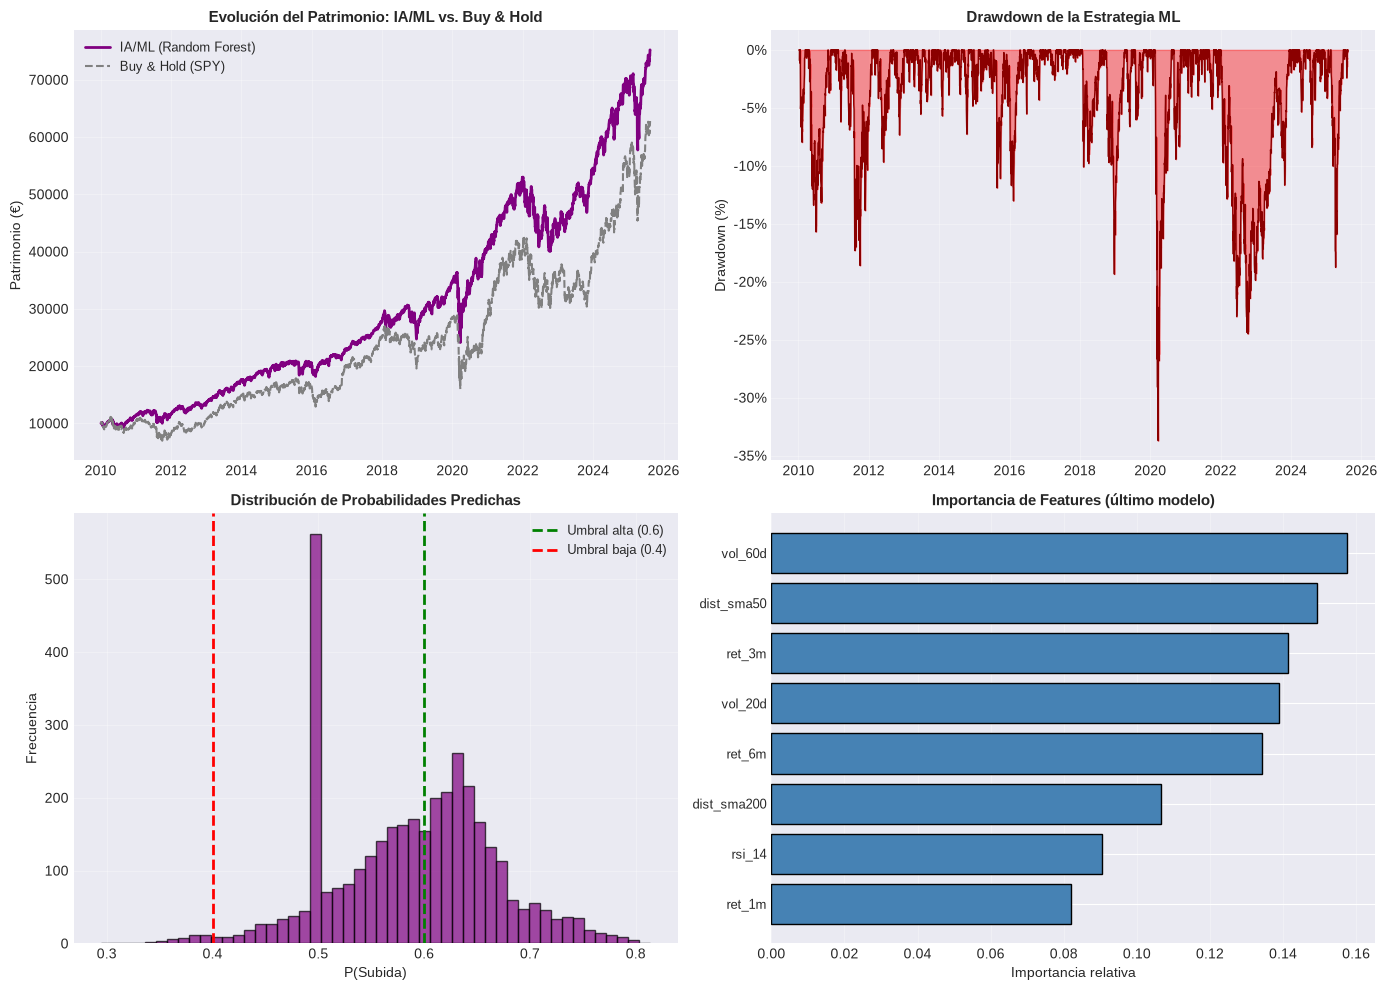


🎯 MATRIZ DE CONFUSIÓN (Último modelo entrenado)

Período de evaluación: 2024-08-13 → 2025-08-14
Accuracy: 0.643

Matriz de confusión:
[[ 10  90]
 [  0 152]]

Reporte de clasificación:
              precision    recall  f1-score   support

  Bajada (0)       1.00      0.10      0.18       100
  Subida (1)       0.63      1.00      0.77       152

    accuracy                           0.64       252
   macro avg       0.81      0.55      0.48       252
weighted avg       0.78      0.64      0.54       252


💡 INTERPRETACIÓN:
• Accuracy ~0.52-0.55: La IA acierta poco más que el azar (50%).
  Esto NO es un fallo: es la realidad de los mercados financieros.
• Si la precisión fuera >0.60 de forma consistente, estaríamos ante 
  una anomalía estadística (o overfitting).
• El valor real del modelo no está en predecir, sino en cuantificar 
  la incertidumbre (probabilidades) y gestionar el riesgo.



In [8]:
# %%
# ==============================================================================
# BLOQUE 8: VISUALIZACIÓN Y DIAGNÓSTICO DEL MODELO ML
# ==============================================================================
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

# --- Gráfico 1: Equity Curve comparativa ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1.1 Equity Curve
axes[0, 0].plot(motor_ml.serie_patrimonio.index, motor_ml.serie_patrimonio,
                label='IA/ML (Random Forest)', color='purple', lw=2)
axes[0, 0].plot(motor_ml.serie_buy_hold.index, motor_ml.serie_buy_hold,
                label='Buy & Hold (SPY)', color='gray', ls='--', lw=1.5)
axes[0, 0].set_title('Evolución del Patrimonio: IA/ML vs. Buy & Hold',
                     fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Patrimonio (€)')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# 1.2 Drawdown
drawdown = (motor_ml.serie_patrimonio / motor_ml.serie_patrimonio.cummax()) - 1
axes[0, 1].fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4)
axes[0, 1].plot(drawdown.index, drawdown, color='darkred', lw=1)
axes[0, 1].set_title('Drawdown de la Estrategia ML', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Drawdown (%)')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0, 1].grid(True, alpha=0.3)

# 1.3 Distribución de probabilidades predichas
axes[1, 0].hist(df_ml['prob_subida'].dropna(), bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(UMBRAL_CONFIANZA_ALTA, color='green', ls='--', lw=2, label=f'Umbral alta ({UMBRAL_CONFIANZA_ALTA})')
axes[1, 0].axvline(UMBRAL_CONFIANZA_BAJA, color='red', ls='--', lw=2, label=f'Umbral baja ({UMBRAL_CONFIANZA_BAJA})')
axes[1, 0].set_title('Distribución de Probabilidades Predichas', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('P(Subida)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# 1.4 Feature Importance
importances = modelo.feature_importances_
sorted_idx = np.argsort(importances)
y_pos = np.arange(len(features))
axes[1, 1].barh(y_pos, importances[sorted_idx], color='steelblue', edgecolor='black')
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels([features[i] for i in sorted_idx], fontsize=9)
axes[1, 1].set_title('Importancia de Features (último modelo)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Importancia relativa')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()

# Guardar gráfico
nombre_archivo = f"ml_random_forest_{FECHA_INICIO[:4]}_{FECHA_FIN[:4]}".lower()
ruta_guardado = Path(gestor_proyecto.DIRS["OUTPUTS_FIGURES"]) / f"{nombre_archivo}.png"
fig.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
print(f"\n✅ Gráfico compuesto guardado en: {ruta_guardado}")
plt.show()

# --- Matriz de Confusión del último modelo ---
print("\n" + "="*70)
print("🎯 MATRIZ DE CONFUSIÓN (Último modelo entrenado)")
print("="*70)

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Predecir sobre los últimos 252 días (1 año) para evaluar
idx_test = df_ml.index >= df_ml.index[-252]
y_true = y[idx_test].values
y_pred = modelo.predict(X[idx_test])

print(f"\nPeríodo de evaluación: {df_ml.index[idx_test][0].date()} → {df_ml.index[idx_test][-1].date()}")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}")
print("\nMatriz de confusión:")
print(confusion_matrix(y_true, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=['Bajada (0)', 'Subida (1)']))

print("""
💡 INTERPRETACIÓN:
• Accuracy ~0.52-0.55: La IA acierta poco más que el azar (50%).
  Esto NO es un fallo: es la realidad de los mercados financieros.
• Si la precisión fuera >0.60 de forma consistente, estaríamos ante 
  una anomalía estadística (o overfitting).
• El valor real del modelo no está en predecir, sino en cuantificar 
  la incertidumbre (probabilidades) y gestionar el riesgo.
""")

## BLOQUE 9: ANÁLISIS DE CORRELACIÓN FINAL


 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO

📊 TABLA DE CORRELACIONES (Retornos Diarios)
                         Financial_Select_Sector  JPMorgan  Bank_of_America  Wells_Fargo  Goldman_Sachs  Morgan_Stanley  Citigroup  BlackRock  Charles_Schwab  American_Express  PNC_Financial  SPDR_S&P_500
Financial_Select_Sector                     1.00      0.91             0.88         0.87           0.85            0.86       0.88       0.79            0.75              0.80           0.87          0.87
JPMorgan                                    0.91      1.00             0.85         0.80           0.81            0.81       0.84       0.68            0.67              0.71           0.81          0.74
Bank_of_America                             0.88      0.85             1.00         0.79           0.78            0.81       0.85       0.66            0.68              0.68           0.80          0.70
Wells_Fargo                                 0.87      0.80             0.79         1.00        

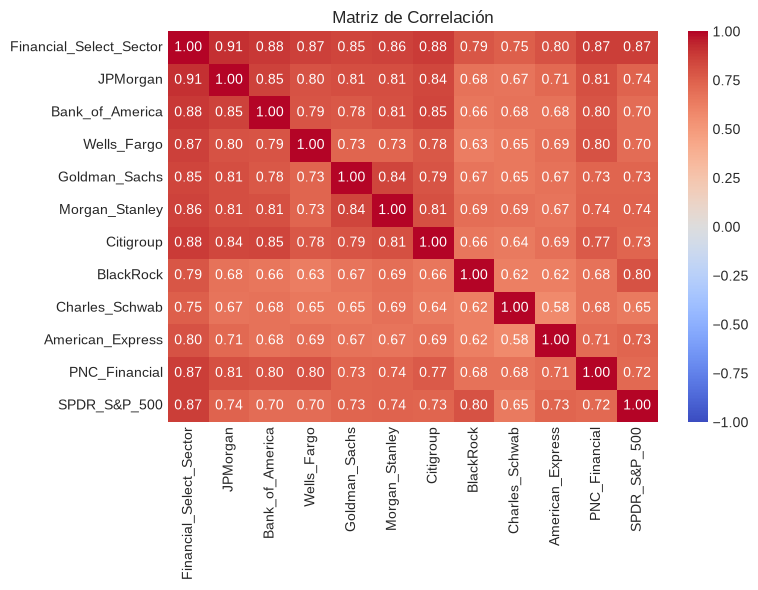


✅ Análisis de correlación completado.

💡 NOTA: En este capítulo la correlación es menos relevante que en los anteriores.
El modelo ML no opera sobre correlaciones entre activos, sino sobre patrones 
temporales dentro de un único activo (SPY). La "diversificación" aquí viene 
dada por la alternancia entre SPY y SHV según la confianza del modelo.



In [9]:
# %%
# ==============================================================================
# BLOQUE 9: ANÁLISIS DE CORRELACIÓN FINAL
# ==============================================================================
print("\n" + "="*70)
print(" ANÁLISIS DE CORRELACIÓN DEL UNIVERSO")
print("="*70)

gestor.calcular_correlacion()

print("\n✅ Análisis de correlación completado.")
print("""
💡 NOTA: En este capítulo la correlación es menos relevante que en los anteriores.
El modelo ML no opera sobre correlaciones entre activos, sino sobre patrones 
temporales dentro de un único activo (SPY). La "diversificación" aquí viene 
dada por la alternancia entre SPY y SHV según la confianza del modelo.
""")

## BLOQUE 10: CONCLUSIONES PEDAGÓGICAS Y CIERRE

In [10]:
# %%
# ==============================================================================
# BLOQUE 10: CONCLUSIONES PEDAGÓGICAS Y CIERRE
# ==============================================================================
print("\n" + "="*70)
print("🎓 CONCLUSIONES DEL CAPÍTULO 7: ALGORITHMIC TRADING CON IA/ML")
print("="*70)
print("""
📌 LECCIONES CLAVE DE ESTE CAPÍTULO
====================================

1. LA IA NO PREDICE EL FUTURO, CUANTIFICA LA INCERTIDUMBRE
   • Un modelo de ML no es una bola de cristal. Es un reconocedor de patrones
     no lineales que asigna probabilidades basadas en el pasado.
   • Una accuracy del 53% no es un fracaso: es la realidad de los mercados
     eficientes con ratio señal/ruido muy baja.

2. EL WALK-FORWARD ES OBLIGATORIO, NO OPCIONAL
   • Un train/test split aleatorio en series temporales es mentira: introduce
     look-ahead bias. El esquema expansivo (reentrenar cada mes con datos
     acumulados) es la única forma honesta de simular la realidad.

3. LA FEATURE IMPORTANCE ES EL VERDADERO ALPHA DEL ML
   • El modelo nos ha enseñado qué variables importan (momentum, volatilidad).
   • Esto confirma lo que ya sabíamos de los capítulos anteriores, pero ahora
     con evidencia cuantitativa, no con intuición.

4. EL OVERFITTING ES EL ENEMIGO SILENCIOSO
   • Un modelo con 100% de accuracy en backtest está sobreajustado.
   • La complejidad del modelo (profundidad del árbol, número de features)
     debe ser mínima para generalizar bien a datos no vistos.

5. EL LÍMITE DEL MOTOR NO ES LA POTENCIA DE CÁLCULO
   • Es la naturaleza de los datos financieros: alta ruido, baja señal,
     regímenes cambiantes. Ningún algoritmo, por sofisticado que sea,
     puede extraer alpha de donde no lo hay.

 HERRAMIENTAS NUEVAS QUE HAS APRENDIDO A USAR
================================================
• Random Forest Classifier para clasificación binaria (sube/baja).
• Feature engineering financiero (momentum, volatilidad, distancia a SMA, RSI).
• Walk-Forward Validation (reentrenamiento expansivo mensual).
• Interpretación de probabilidades calibradas (no solo predicciones duras).
• Matriz de confusión y accuracy como métricas de diagnóstico.

📊 INTERPRETACIÓN HONESTA DE LOS RESULTADOS
==============================================
Si tu backtest ML tiene:
• CAGR similar o inferior al Buy & Hold → NORMAL. Es lo esperado.
• Max Drawdown menor que el Buy & Hold → ÉXITO. La IA gestionó el riesgo.
• Accuracy entre 50-55% → REALISTA. No caigas en la trampa del overfitting.
• Accuracy > 60% → SOSPECHOSO. Revisa si hay look-ahead bias.

🚪 PRÓXIMO PASO
================
En el Capítulo 8 (y último) veremos cómo integrar TODAS las estrategias
de este libro en un modelo Core-Satellite, asignando pesos dinámicos
según el régimen de mercado detectado por... sí, un modelo de ML.

🎯 RECUERDA
============
El Algorithmic Trading con IA/ML no es un atajo para batir al mercado.
Es una herramienta para:
1. Cuantificar patrones no lineales que las reglas simples no capturan.
2. Gestionar el riesgo de forma adaptativa (probabilidades, no binarios).
3. Entender qué variables importan realmente (feature importance).

La disciplina estadística, la validación rigurosa (walk-forward) y la
humildad intelectual (aceptar que la accuracy será ~53%) son tus
mayores aliados. Quien te prometa un 70% de accuracy en mercados
financieros te está vendiendo humo... o overfitting.
""")
print("="*70)

# --- AVISO LEGAL Y EXENCIÓN DE RESPONSABILIDADES ---
print("\n" + "="*70)
print("⚠️  AVISO LEGAL Y EXENCIÓN DE RESPONSABILIDADES")
print("="*70)
print("""
Este capítulo y todo el código asociado tienen fines EXCLUSIVAMENTE
EDUCATIVOS y de INVESTIGACIÓN CUANTITATIVA.

1. LOS RESULTADOS PASADOS NO GARANTIZAN RESULTADOS FUTUROS
   El backtest presentado es una simulación histórica. Que el modelo ML
   haya generado cierto CAGR en ese período no significa que vaya a
   repetirlo. Los patrones que el modelo aprendió pueden no repetirse.

2. LIMITACIONES ESPECÍFICAS DEL ML EN FINANZAS
   • Overfitting: Un modelo puede memorizar el pasado sin aprender patrones
     generalizables. La validación walk-forward mitiga, pero no elimina,
     este riesgo.
   • Concept Drift: Los patrones de mercado cambian con el tiempo. Un modelo
     entrenado en 2010-2020 puede no funcionar en 2020-2030.
   • Ratio señal/ruido: Los mercados financieros tienen una ratio señal/ruido
     muy baja (~0.05). Esperar accuracies altas es irrealista.
   • Costes de transacción: El ML puede generar muchas señales pequeñas que,
     tras costes, no son rentables.

3. NO ES ASESORAMIENTO FINANCIERO
   Ni el autor, ni el código, ni las métricas generadas constituyen una
   recomendación de inversión personalizada. Cada inversor debe evaluar
   su propia tolerancia al riesgo y consultar con un asesor financiero
   independiente.

4. RIESGO DE PÉRDIDA DE CAPITAL
   Operar con modelos de ML conlleva riesgos específicos: el modelo puede
   fallar silenciosamente (concept drift) y generar pérdidas acumuladas
   antes de que el inversor lo detecte. Un sistema de monitoreo continuo
   es obligatorio en producción.

5. USO DEL CÓDIGO
   El software se entrega "TAL CUAL" (AS IS), sin garantía de ningún tipo.
   El autor no se hace responsable de errores en el código, en los datos
   descargados, ni de pérdidas económicas derivadas de su uso.
""")
print("="*70)
print("✅ CAPÍTULO 7 COMPLETADO")
print("="*70)


🎓 CONCLUSIONES DEL CAPÍTULO 7: ALGORITHMIC TRADING CON IA/ML

📌 LECCIONES CLAVE DE ESTE CAPÍTULO

1. LA IA NO PREDICE EL FUTURO, CUANTIFICA LA INCERTIDUMBRE
   • Un modelo de ML no es una bola de cristal. Es un reconocedor de patrones
     no lineales que asigna probabilidades basadas en el pasado.
   • Una accuracy del 53% no es un fracaso: es la realidad de los mercados
     eficientes con ratio señal/ruido muy baja.

2. EL WALK-FORWARD ES OBLIGATORIO, NO OPCIONAL
   • Un train/test split aleatorio en series temporales es mentira: introduce
     look-ahead bias. El esquema expansivo (reentrenar cada mes con datos
     acumulados) es la única forma honesta de simular la realidad.

3. LA FEATURE IMPORTANCE ES EL VERDADERO ALPHA DEL ML
   • El modelo nos ha enseñado qué variables importan (momentum, volatilidad).
   • Esto confirma lo que ya sabíamos de los capítulos anteriores, pero ahora
     con evidencia cuantitativa, no con intuición.

4. EL OVERFITTING ES EL ENEMIGO SILENCIOSO
  